<a href="https://colab.research.google.com/github/saulotorres7031-stack/Tareas1/blob/main/Housing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Paquetería básica
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Importamos Tensorflow y Keras
import tensorflow as tf
from tensorflow import keras

# Usamos funcionalidades básicas de Sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from keras.callbacks import ModelCheckpoint


In [2]:
!wget 'https://github.com/Dr-Carlos-Villasenor/Clase_Aprendizaje_Profundo/raw/main/Datasets/Housing.csv'

--2026-03-13 05:29:37--  https://github.com/Dr-Carlos-Villasenor/Clase_Aprendizaje_Profundo/raw/main/Datasets/Housing.csv
Resolving github.com (github.com)... 140.82.114.4
Connecting to github.com (github.com)|140.82.114.4|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/Dr-Carlos-Villasenor/Clase_Aprendizaje_Profundo/main/Datasets/Housing.csv [following]
--2026-03-13 05:29:38--  https://raw.githubusercontent.com/Dr-Carlos-Villasenor/Clase_Aprendizaje_Profundo/main/Datasets/Housing.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 29981 (29K) [text/plain]
Saving to: ‘Housing.csv.6’

Housing.csv.6       100%[===================>]  29.28K  --.-KB/s    in 0.003s  

2026-03-13 05:29:38 (10.1 MB/s)

In [3]:
dataset = pd.read_csv('Housing.csv')
dataset.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [4]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [5]:
np.array(dataset)

array([[13300000, 7420, 4, ..., 2, 'yes', 'furnished'],
       [12250000, 8960, 4, ..., 3, 'no', 'furnished'],
       [12250000, 9960, 3, ..., 2, 'yes', 'semi-furnished'],
       ...,
       [1750000, 3620, 2, ..., 0, 'no', 'unfurnished'],
       [1750000, 2910, 3, ..., 0, 'no', 'furnished'],
       [1750000, 3850, 3, ..., 0, 'no', 'unfurnished']], dtype=object)

Cambio salida a categorica

In [6]:
cols = dataset.columns[dataset.isin(['yes','no']).any()]
for col in cols:
    dataset[col] = dataset[col].map({'yes':1,'no':0})

One-Hot

In [7]:
changes = dataset.pop('furnishingstatus')
dataset['Furnished'] = (changes == 'furnished')*1.0
dataset['Semi-furnuished'] = (changes == 'semi-furnished')*1.0
dataset['Unfurnished'] = (changes == 'unfurnished')*1.0
dataset.tail()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,Furnished,Semi-furnuished,Unfurnished
540,1820000,3000,2,1,1,1,0,1,0,0,2,0,0.0,0.0,1.0
541,1767150,2400,3,1,1,0,0,0,0,0,0,0,0.0,1.0,0.0
542,1750000,3620,2,1,1,1,0,0,0,0,0,0,0.0,0.0,1.0
543,1750000,2910,3,1,1,0,0,0,0,0,0,0,1.0,0.0,0.0
544,1750000,3850,3,1,2,1,0,0,0,0,0,0,0.0,0.0,1.0


Variables de entrada y salida

In [8]:
x = np.asanyarray(dataset.drop(columns=['price']))
y = np.asanyarray(dataset[['price']])
x = StandardScaler().fit_transform(x)
y = StandardScaler().fit_transform(y)
print(x.shape)
print(y.shape)

(545, 14)
(545, 1)


Particionar el dataset

In [9]:
xtrain, xtest, ytrain, ytest = train_test_split(x, y, test_size=0.3)

Red neuronal para aprender los datos. En este caso creamos la metrica de regresión R2,

In [10]:
def build_model():

  model = keras.Sequential()
  model.add(keras.layers.Dense(64, activation='relu', input_shape=[x.shape[1]]))
  model.add(keras.layers.Dense(32, activation='relu'))
  model.add(keras.layers.Dropout(0.6))
  model.add(keras.layers.Dense(16, activation='relu'))
  model.add(keras.layers.Dropout(0.6))
  model.add(keras.layers.Dense(1, activation='linear'))

  model.compile(
    loss='mean_squared_error',
    optimizer=keras.optimizers.Adam(),
    metrics=[
        keras.metrics.MeanAbsoluteError(),
        keras.metrics.R2Score()])
  return  model

In [11]:
es = keras.callbacks.EarlyStopping(monitor='val_loss', mode='min', patience=20)

checkpoint = ModelCheckpoint(
    filepath="House.keras",   # nombre del archivo
    monitor="val_loss",              # métrica que se vigila
    save_best_only=True,             # guarda solo el mejor
    save_weights_only=False,         # guarda todo el modelo
    mode="min",                      # porque queremos minimizar loss
    verbose=0
)

model = build_model()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Entrenar la red neuronal

In [12]:
history = model.fit(xtrain, ytrain,
                    batch_size=150, epochs=500,
                    validation_data=(xtest, ytest), verbose=0)

loss, mae, r2 = model.evaluate(xtest, ytest, batch_size=150)

print("Loss:", loss)
print("MAE:", mae)
print("R2:", r2)

loss, mae, r2 = model.evaluate(xtrain, ytrain, batch_size=150)

print("Train Loss:", loss)
print("Train MAE:", mae)
print("Train R2:", r2)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.4763 - mean_absolute_error: 0.5010 - r2_score: 0.5208
Loss: 0.47630590200424194
MAE: 0.5009869337081909
R2: 0.5208490490913391
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.1436 - mean_absolute_error: 0.2811 - r2_score: 0.8565
Train Loss: 0.1435602903366089
Train MAE: 0.2810567617416382
Train R2: 0.856514573097229


Dibuja las curvas de aprendizaje para un mejor diagnóstico del aprendizaje

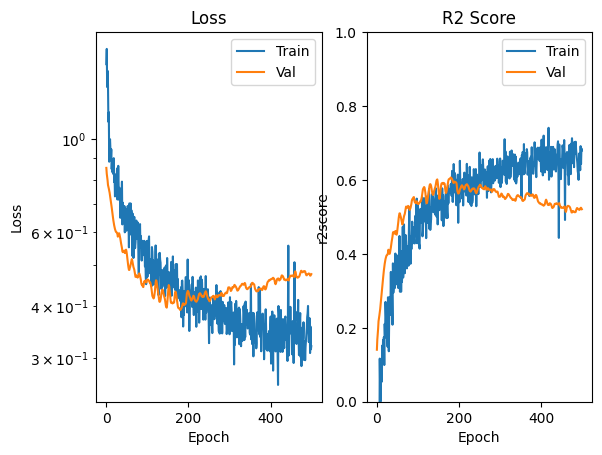

In [13]:
def plot_history(history):
  hist = pd.DataFrame(history.history)
  hist['epoch'] = history.epoch
  plt.figure()
  plt.subplot(121)
  plt.title('Loss')
  plt.xlabel('Epoch')
  plt.ylabel('Loss')
  plt.plot(hist['epoch'], hist['loss'],
           label='Train')
  plt.plot(hist['epoch'], hist['val_loss'],
           label = 'Val')
  plt.yscale('log')
  plt.legend()

  plt.subplot(122)
  plt.title('R2 Score')
  plt.xlabel('Epoch')
  plt.ylabel('r2score')
  plt.plot(hist['epoch'], hist['r2_score'],
           label='Train')
  plt.plot(hist['epoch'], hist['val_r2_score'],
           label = 'Val')
  plt.ylim([0,1])
  plt.legend()

plot_history(history)